Промышленность

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li>
    <span><a href="#environments" data-toc-modified-id="environments"><span class="toc-item-num">0&nbsp;&nbsp;</span>environments</a></span></li><li>
    <span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка данных</a></span></li><li>
    <span><a href="#Анализ-данных" data-toc-modified-id="Анализ-данных"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ данных</a></span></li><li>
    <span><a href="#Модель" data-toc-modified-id="Модель"><span class="toc-item-num">3&nbsp;&nbsp;</span>Модель</a></span></li><li>
    <span><a href="#Отчет" data-toc-modified-id="Отчет"><span class="toc-item-num">4&nbsp;&nbsp;</span>Отчет</a></span></li><li>

**Описание проекта**

Компания решила уменьшить потребление электроэнергии на этапе обработки стали.
Требуется подготовить модель, которая предскажет температуру стали.

**Цель проекта**

Подготовить прототип модели машинного обучения, которая предскажет температуру стали.

**Описание данных**

Данные находятся в `datasets/` и состоят из файлов, полученных из разных источников:

- `data_arc_new.csv` — данные об электродах;
- `data_bulk_new.csv` — данные о подаче сыпучих материалов (объём);
- `data_bulk_time_new.csv` *—* данные о подаче сыпучих материалов (время);
- `data_gas_new.csv` — данные о продувке сплава газом;
- `data_temp_new.csv` — результаты измерения температуры;
- `data_wire_new.csv` — данные о проволочных материалах (объём);
- `data_wire_time_new.csv` — данные о проволочных материалах (время).

***Особенности набора данных***

Во всех файлах столбец `key` содержит номер партии. В файлах может быть несколько строк с одинаковым значением `key`: они соответствуют разным итерациям обработки.

**Условия и ограничения**

* Провести анализ важности факторов, которые оказывают влияние на температуру стали на этапе ее обработки (SHAP, SHapley Additive exPlanations: https://github.com/slundberg/shap).
* Для оценки качества модели использовать метрику MAE (*mean absolute error*), значение которой на тестовой выборке должно быть не больше $6.8$
* В объединённом датафрейме должны быть только те ключи, которые есть во всех датафреймах.
* Для генерации псевдослучайных чисел следует использовать значение `080523`
* Доля тестовой выборки должна составлять $0.25$
* Следует рассмотреть не менее трех моделей, при этом хотя бы для одной модели подбор гиперпараметров должен быть выполнен в автоматизированном режиме.

***Технологический процесс***

Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн. Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом. Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены в крышке ковша.

Из сплава выводится сера (десульфурация), добавлением примесей корректируется химический состав и отбираются пробы. Сталь легируют — изменяют её состав — подавая куски сплава из бункера для сыпучих материалов или проволоку через специальный трайб-аппарат (англ. tribe, «масса»).

Перед тем как первый раз ввести легирующие добавки, измеряют температуру стали и производят её химический анализ. Потом температуру на несколько минут повышают, добавляют легирующие материалы и продувают сплав инертным газом. Затем его перемешивают и снова проводят измерения. Такой цикл повторяется до достижения целевого химического состава и оптимальной температуры плавки.

Тогда расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки. Оттуда готовый продукт выходит в виде заготовок-слябов (англ. slab, «плита»).

# План работы

1. Загрузить и подготовить данные
2. Провести анализ данных
3. Построить модель прогнозирования
4. Составить отчет о проделанной работе

## environments

In [1]:
try:
    import shap
except:
    !pip install shap
finally:
    import shap

In [2]:
import os
import xgboost
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet)
from sklearn.model_selection import (
    GridSearchCV, cross_val_score, train_test_split, RepeatedKFold)

from sklearn.exceptions import ConvergenceWarning
pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

RANDOM_STATE = '080523'
TEST_SIZE = 0.25

# Подготовка данных

## Работа с `data_temp_new.csv`

Нашел датасет на kaggle (https://www.kaggle.com/datasets/yuriykatser/industrial-data-from-the-ladlefurnace-unit) с дополненным csv, буду работать с ним

In [3]:
temp = pd.read_csv('data_temp_FULL_with_test.csv')
temp['time'] = pd.to_datetime(temp['time'])
print(temp.dtypes)
temp.head(12)

key                     int64
time           datetime64[ns]
Temperature           float64
dtype: object


,key,time,Temperature
0,1,2019-05-03 11:16:18,1571.0
1,1,2019-05-03 11:25:53,1604.0
2,1,2019-05-03 11:29:11,1618.0
3,1,2019-05-03 11:30:01,1601.0
4,1,2019-05-03 11:30:39,1613.0
5,2,2019-05-03 11:37:27,1581.0
6,2,2019-05-03 11:38:00,1577.0
7,2,2019-05-03 11:49:38,1589.0
8,2,2019-05-03 11:55:50,1604.0
9,2,2019-05-03 11:58:24,1608.0


In [4]:
temp.describe()

,key,time,Temperature
count,15907.000000,15907,15907.000000
mean,1607.880870,2019-07-02 09:55:01.000942848,1592.149431
min,1.000000,2019-05-03 11:16:18,1189.000000
25%,790.000000,2019-06-01 16:24:51.500000,1581.000000
50%,1618.000000,2019-06-30 10:31:14,1591.000000
75%,2427.000000,2019-08-03 12:07:59,1601.000000
max,3241.000000,2019-09-01 04:38:08,1705.000000
std,942.212073,NaN,21.058244


In [5]:
rows = []
for k, g in temp.groupby('key', sort=True):
    g = g.sort_values('time').reset_index(drop=True)
    g = g.dropna(subset=['Temperature'])
    last = g.iloc[-1]
    time_last = last['time']
    temp_last = last['Temperature']
    if len(g) >= 2:
        prev_temp = g.iloc[-2]['Temperature']
        prev_temp_mean = g['Temperature'].iloc[:-1].mean()
        is_first_measure = 0
    else:
        prev_temp = 0
        prev_temp_mean = 0
        is_first_measure = 1

    rows.append({
        'key': k,
        'time_last': time_last,
        'temp_last': temp_last,
        'prev_temp': prev_temp,
        'prev_temp_mean': prev_temp_mean,
        'is_first_measure': is_first_measure
    })

temp_processed = pd.DataFrame(rows)
temp_processed

,key,time_last,temp_last,prev_temp,prev_temp_mean,is_first_measure
0,1,2019-05-03 11:30:39,1613.0,1601.0,1598.500000,0
1,2,2019-05-03 11:59:12,1602.0,1608.0,1591.800000,0
2,3,2019-05-03 12:34:57,1599.0,1599.0,1597.500000,0
3,4,2019-05-03 12:59:25,1625.0,1623.0,1612.000000,0
4,5,2019-05-03 13:36:01,1602.0,1576.0,1576.000000,0
...,...,...,...,...,...,...
3211,3237,2019-08-31 23:05:43,1596.0,1587.0,1571.500000,0
3212,3238,2019-08-31 23:43:00,1598.0,1589.0,1586.500000,0
3213,3239,2019-09-01 02:24:15,1613.0,1614.0,1608.142857,0
3214,3240,2019-09-01 03:35:16,1594.0,1591.0,1596.714286,0


In [6]:
# Их нет в data_arc_new.csv, они не пойдут в итоговый dataframe
key_with_first_measure = temp_processed[temp_processed['is_first_measure'] == 1]['key'].to_numpy()
key_with_first_measure[:10], key_with_first_measure.shape

(array([195, 279]), (2,))

## Работа с `data_arc_new.csv`

In [7]:
arc = pd.read_csv('data_arc_new.csv')
arc['Начало нагрева дугой'] = pd.to_datetime(arc['Начало нагрева дугой'])
arc['Конец нагрева дугой'] = pd.to_datetime(arc['Конец нагрева дугой'])
print(arc.dtypes)
arc.head(10)

key                              int64
Начало нагрева дугой    datetime64[ns]
Конец нагрева дугой     datetime64[ns]
Активная мощность              float64
Реактивная мощность            float64
dtype: object


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.976059,0.687084
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.805607,0.520285
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.744363,0.498805
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,1.659363,1.062669
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.692755,0.414397
5,2,2019-05-03 11:34:14,2019-05-03 11:36:31,0.438063,0.283043
6,2,2019-05-03 11:38:50,2019-05-03 11:44:28,1.296415,0.892914
7,2,2019-05-03 11:46:19,2019-05-03 11:48:25,0.490377,0.305281
8,2,2019-05-03 11:49:48,2019-05-03 11:53:18,0.827743,0.516874
9,3,2019-05-03 12:06:54,2019-05-03 12:11:34,1.062053,0.671494


In [8]:
arc.describe()

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
count,14876.000000,14876,14876,14876.000000,14876.000000
mean,1615.220422,2019-07-02 16:15:28.218203904,2019-07-02 16:18:19.889150208,0.670441,0.452592
min,1.000000,2019-05-03 11:02:14,2019-05-03 11:06:02,0.030002,-715.504924
25%,806.000000,2019-06-02 07:01:09.249999872,2019-06-02 07:04:21,0.395297,0.290991
50%,1617.000000,2019-06-30 09:57:14.500000,2019-06-30 10:01:01,0.555517,0.415962
75%,2429.000000,2019-08-03 13:04:47.750000128,2019-08-03 13:09:14,0.857034,0.637371
max,3241.000000,2019-09-01 04:34:47,2019-09-01 04:36:08,3.731596,2.676388
std,934.571502,NaN,NaN,0.408159,5.878702


In [9]:
arc[arc['Реактивная мощность'] < 0]

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
9780,2116,2019-07-24 00:44:48,2019-07-24 00:46:37,0.495782,-715.504924


In [10]:
arc.loc[9780, 'Реактивная мощность'] = 0

In [11]:
rows = []
for k, g in arc.groupby('key', sort=True):
    g = g.sort_values('Конец нагрева дугой').reset_index(drop=True)
    k_time_last = temp_processed[temp_processed['key'] == k]['time_last']
    for i in range(1, len(g)+1):
        last = g.iloc[-i]
        if (k_time_last - last['Конец нагрева дугой']).dt.total_seconds().iloc[0] > 0:
            j = i
            break
    time_heating = (last['Конец нагрева дугой'] - \
    last['Начало нагрева дугой']).total_seconds()
    active_power = last['Активная мощность']
    reactive_power = last['Реактивная мощность']
    active_power_mean = g['Активная мощность'].iloc[:-j].mean()
    reactive_power_mean = g['Реактивная мощность'].iloc[:-j].mean()
    last_heating = last['Конец нагрева дугой']

    rows.append({
        'key': k,
        'time_heating': time_heating,
        'active_power': active_power,
        'reactive_power': reactive_power,
        'active_power_mean': active_power_mean,
        'reactive_power_mean': reactive_power_mean,
        'last_heating': last_heating
    })

arc_processed = pd.DataFrame(rows)
arc_processed

,key,time_heating,active_power,reactive_power,active_power_mean,reactive_power_mean,last_heating
0,1,148.0,0.692755,0.414397,1.046348,0.692211,2019-05-03 11:28:37
1,2,210.0,0.827743,0.516874,0.741618,0.493746,2019-05-03 11:53:18
2,3,65.0,0.250280,0.155901,0.568901,0.360794,2019-05-03 12:32:19
3,4,278.0,1.220955,0.754719,0.662765,0.435193,2019-05-03 12:57:50
4,5,71.0,0.267457,0.181992,1.026572,0.690217,2019-05-03 13:33:55
...,...,...,...,...,...,...,...
3209,3237,136.0,0.606049,0.419084,0.831605,0.602344,2019-08-31 23:03:48
3210,3238,170.0,0.717559,0.520623,0.694485,0.580280,2019-08-31 23:41:28
3211,3239,125.0,0.488352,0.317727,0.596915,0.399127,2019-09-01 02:15:43
3212,3240,141.0,0.548882,0.416994,0.608800,0.516568,2019-09-01 03:34:08


## Работа с `data_bulk_new.csv` и `data_bulk_time_new.csv`

In [12]:
bulk = pd.read_csv('data_bulk_new.csv')
print(bulk.shape, len(np.unique(bulk.index)))
print(bulk.dtypes)
bulk.head()

(3129, 16) 3129
key          int64
Bulk 1     float64
Bulk 2     float64
Bulk 3     float64
Bulk 4     float64
Bulk 5     float64
Bulk 6     float64
Bulk 7     float64
Bulk 8     float64
Bulk 9     float64
Bulk 10    float64
Bulk 11    float64
Bulk 12    float64
Bulk 13    float64
Bulk 14    float64
Bulk 15    float64
dtype: object


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0


In [13]:
bulk.describe()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.000000,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,1624.383509,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,933.337642,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,1.000000,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,816.000000,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,1622.000000,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,2431.000000,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


In [14]:
bulk_time = pd.read_csv('data_bulk_time_new.csv')
for column in bulk_time.columns[1:]:
    bulk_time[column] = pd.to_datetime(bulk_time[column])
bulk_time = bulk_time.set_index('key').add_suffix('_time').reset_index()
print(bulk_time.shape, len(np.unique(bulk_time.index)))
print(bulk_time.dtypes)
bulk_time.head()

(3129, 16) 3129
key                      int64
Bulk 1_time     datetime64[ns]
Bulk 2_time     datetime64[ns]
Bulk 3_time     datetime64[ns]
Bulk 4_time     datetime64[ns]
Bulk 5_time     datetime64[ns]
Bulk 6_time     datetime64[ns]
Bulk 7_time     datetime64[ns]
Bulk 8_time     datetime64[ns]
Bulk 9_time     datetime64[ns]
Bulk 10_time    datetime64[ns]
Bulk 11_time    datetime64[ns]
Bulk 12_time    datetime64[ns]
Bulk 13_time    datetime64[ns]
Bulk 14_time    datetime64[ns]
Bulk 15_time    datetime64[ns]
dtype: object


,key,Bulk 1_time,Bulk 2_time,Bulk 3_time,Bulk 4_time,Bulk 5_time,Bulk 6_time,Bulk 7_time,Bulk 8_time,Bulk 9_time,Bulk 10_time,Bulk 11_time,Bulk 12_time,Bulk 13_time,Bulk 14_time,Bulk 15_time
0,1,NaT,NaT,NaT,2019-05-03 11:21:30,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:03:52,NaT,2019-05-03 11:03:52,2019-05-03 11:03:52
1,2,NaT,NaT,NaT,2019-05-03 11:46:38,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:40:20,NaT,2019-05-03 11:40:20,2019-05-03 11:40:20
2,3,NaT,NaT,NaT,2019-05-03 12:31:06,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:09:40,NaT,2019-05-03 12:09:40,2019-05-03 12:09:40
3,4,NaT,NaT,NaT,2019-05-03 12:48:43,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:41:24,NaT,2019-05-03 12:41:24,2019-05-03 12:41:24
4,5,NaT,NaT,NaT,2019-05-03 13:18:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:12:56,NaT,2019-05-03 13:12:56,2019-05-03 13:12:56


## Работа с `data_gas_new.csv`

In [15]:
gas = pd.read_csv('data_gas_new.csv')
gas = gas.rename(columns={'Газ 1': 'gas'})
print(gas.dtypes)
gas.head()

key      int64
gas    float64
dtype: object


,key,gas
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


In [16]:
gas.describe()

,key,gas
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


## Работа с `data_wire_new.csv` и `data_wire_time_new.csv`

In [17]:
wire = pd.read_csv('data_wire_new.csv')
print(wire.shape, len(np.unique(wire.index)))
print(wire.dtypes)
wire.head()

(3081, 10) 3081
key         int64
Wire 1    float64
Wire 2    float64
Wire 3    float64
Wire 4    float64
Wire 5    float64
Wire 6    float64
Wire 7    float64
Wire 8    float64
Wire 9    float64
dtype: object


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
wire.describe()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000000,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,1623.426485,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,932.996726,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.000000,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,823.000000,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,1619.000000,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,2434.000000,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,3241.000000,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


In [19]:
wire_time = pd.read_csv('data_wire_time_new.csv')
for column in wire_time.columns[1:]:
    wire_time[column] = pd.to_datetime(wire_time[column])
wire_time = wire_time.set_index('key').add_suffix('_time').reset_index()
print(wire_time.shape, len(np.unique(wire_time.index)))
print(wire_time.dtypes)
wire_time.head()

(3081, 10) 3081
key                     int64
Wire 1_time    datetime64[ns]
Wire 2_time    datetime64[ns]
Wire 3_time    datetime64[ns]
Wire 4_time    datetime64[ns]
Wire 5_time    datetime64[ns]
Wire 6_time    datetime64[ns]
Wire 7_time    datetime64[ns]
Wire 8_time    datetime64[ns]
Wire 9_time    datetime64[ns]
dtype: object


,key,Wire 1_time,Wire 2_time,Wire 3_time,Wire 4_time,Wire 5_time,Wire 6_time,Wire 7_time,Wire 8_time,Wire 9_time
0,1,2019-05-03 11:11:41,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2,2019-05-03 11:46:10,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2,3,2019-05-03 12:13:47,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
3,4,2019-05-03 12:48:05,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
4,5,2019-05-03 13:18:15,2019-05-03 13:32:06,NaT,NaT,NaT,NaT,NaT,NaT,NaT


## Общий датафрейм

In [20]:
df = temp_processed.merge(arc_processed, on='key').merge(bulk, on='key').\
merge(bulk_time, on='key').merge(gas, on='key').merge(wire, on='key').\
merge(wire_time, on='key')

datetime_columns = ['last_heating'] + list(bulk_time.columns[1:]) \
+ list(wire_time.columns[1:])

for dc in datetime_columns:
    df[dc] = (df['time_last'] - df[dc]).dt.total_seconds()

keys_to_drop = []
for k in df.index:
    if (df.loc[k, datetime_columns] < 0).sum() > 0:
        keys_to_drop.append(k)
df = df.drop(index=keys_to_drop)

df = df.set_index('key')
df = df.drop(columns=['time_last', 'is_first_measure'])
df = df.fillna(0)
df

,temp_last,prev_temp,prev_temp_mean,time_heating,active_power,reactive_power,active_power_mean,reactive_power_mean,last_heating,Bulk 1,...,Wire 9,Wire 1_time,Wire 2_time,Wire 3_time,Wire 4_time,Wire 5_time,Wire 6_time,Wire 7_time,Wire 8_time,Wire 9_time
key,,,,,,,,,,,,,,,,,,,,,
1,1613.0,1601.0,1598.500000,148.0,0.692755,0.414397,1.046348,0.692211,122.0,0.0,...,0.0,1138.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1602.0,1608.0,1591.800000,210.0,0.827743,0.516874,0.741618,0.493746,354.0,0.0,...,0.0,782.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1599.0,1599.0,1597.500000,65.0,0.250280,0.155901,0.568901,0.360794,158.0,0.0,...,0.0,1270.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1625.0,1623.0,1612.000000,278.0,1.220955,0.754719,0.662765,0.435193,95.0,0.0,...,0.0,680.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1602.0,1576.0,1576.000000,71.0,0.267457,0.181992,1.026572,0.690217,126.0,0.0,...,0.0,1066.0,235.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3237,1596.0,1587.0,1571.500000,136.0,0.606049,0.419084,0.831605,0.602344,115.0,0.0,...,0.0,923.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3238,1598.0,1589.0,1586.500000,170.0,0.717559,0.520623,0.694485,0.580280,92.0,0.0,...,0.0,276.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3239,1613.0,1614.0,1608.142857,125.0,0.488352,0.317727,0.596915,0.399127,512.0,0.0,...,0.0,2012.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Анализ данных

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temp_last,3012.0,1593.314409,11.389124,1539.000000,1587.000000,1593.000000,1598.000000,1653.000000
prev_temp,3012.0,1591.084993,12.605664,1536.000000,1584.000000,1591.000000,1598.000000,1662.000000
prev_temp_mean,3012.0,1588.300206,14.459232,1496.250000,1579.333333,1588.500000,1597.666667,1643.666667
time_heating,3012.0,121.514276,62.930052,11.000000,75.000000,107.000000,152.000000,555.000000
active_power,3012.0,0.495176,0.268982,0.030002,0.301016,0.433495,0.622378,2.337050
reactive_power,3012.0,0.357993,0.196824,0.021154,0.215547,0.315133,0.448817,1.495166
active_power_mean,3012.0,0.710539,0.238588,0.000000,0.542756,0.690113,0.853150,1.730631
reactive_power_mean,3012.0,0.536254,0.182430,0.000000,0.411026,0.522885,0.645214,1.500087
last_heating,3012.0,229.383466,275.600059,9.000000,65.000000,133.000000,277.000000,2400.000000
Bulk 1,3012.0,3.283201,12.080894,0.000000,0.000000,0.000000,0.000000,185.000000


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3012 entries, 1 to 3241
Data columns (total 58 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temp_last            3012 non-null   float64
 1   prev_temp            3012 non-null   float64
 2   prev_temp_mean       3012 non-null   float64
 3   time_heating         3012 non-null   float64
 4   active_power         3012 non-null   float64
 5   reactive_power       3012 non-null   float64
 6   active_power_mean    3012 non-null   float64
 7   reactive_power_mean  3012 non-null   float64
 8   last_heating         3012 non-null   float64
 9   Bulk 1               3012 non-null   float64
 10  Bulk 2               3012 non-null   float64
 11  Bulk 3               3012 non-null   float64
 12  Bulk 4               3012 non-null   float64
 13  Bulk 5               3012 non-null   float64
 14  Bulk 6               3012 non-null   float64
 15  Bulk 7               3012 non-null   float6

# Модель

In [23]:
RANDOM_STATE = int(RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['temp_last']), df['temp_last'],
    test_size=TEST_SIZE, random_state=RANDOM_STATE)

In [24]:
dummy = DummyRegressor()
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
mean_absolute_error(y_test, dummy_pred)

8.375318557553765

In [25]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)
linreg_pred = linreg.predict(X_test)
mean_absolute_error(y_test, linreg_pred)

3.2930757853409367

In [26]:
gbr = GradientBoostingRegressor(random_state=RANDOM_STATE)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(gbr, param_grid, verbose=2,
                           scoring = 'neg_mean_absolute_error')
grid_search.fit(X_train, y_train)

print('\nЛучшие параметры:', grid_search.best_params_)
print('CV MAE:', -grid_search.best_score_)

gbr_best_model = grid_search.best_estimator_
gbr_pred = gbr_best_model.predict(X_test)
print('\nTest MAE:', mean_absolute_error(y_test, gbr_pred))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .......max_depth=2, n_estimators=100, subsample=0.8; total time=   1.0s
[CV] END .......max_depth=2, n_estimators=100, subsample=0.8; total time=   1.0s
[CV] END .......max_depth=2, n_estimators=100, subsample=0.8; total time=   1.3s
[CV] END .......max_depth=2, n_estimators=100, subsample=0.8; total time=   1.3s
[CV] END .......max_depth=2, n_estimators=100, subsample=0.8; total time=   1.0s
[CV] END .......max_depth=2, n_estimators=100, subsample=1.0; total time=   1.1s
[CV] END .......max_depth=2, n_estimators=100, subsample=1.0; total time=   1.1s
[CV] END .......max_depth=2, n_estimators=100, subsample=1.0; total time=   1.1s
[CV] END .......max_depth=2, n_estimators=100, subsample=1.0; total time=   1.1s
[CV] END .......max_depth=2, n_estimators=100, subsample=1.0; total time=   1.1s
[CV] END .......max_depth=2, n_estimators=200, subsample=0.8; total time=   1.9s
[CV] END .......max_depth=2, n_estimators=200, s

# Тестирование лучшей модели

In [27]:
explainer = shap.Explainer(gbr_best_model, X_train)
shap_values = explainer(X_train)

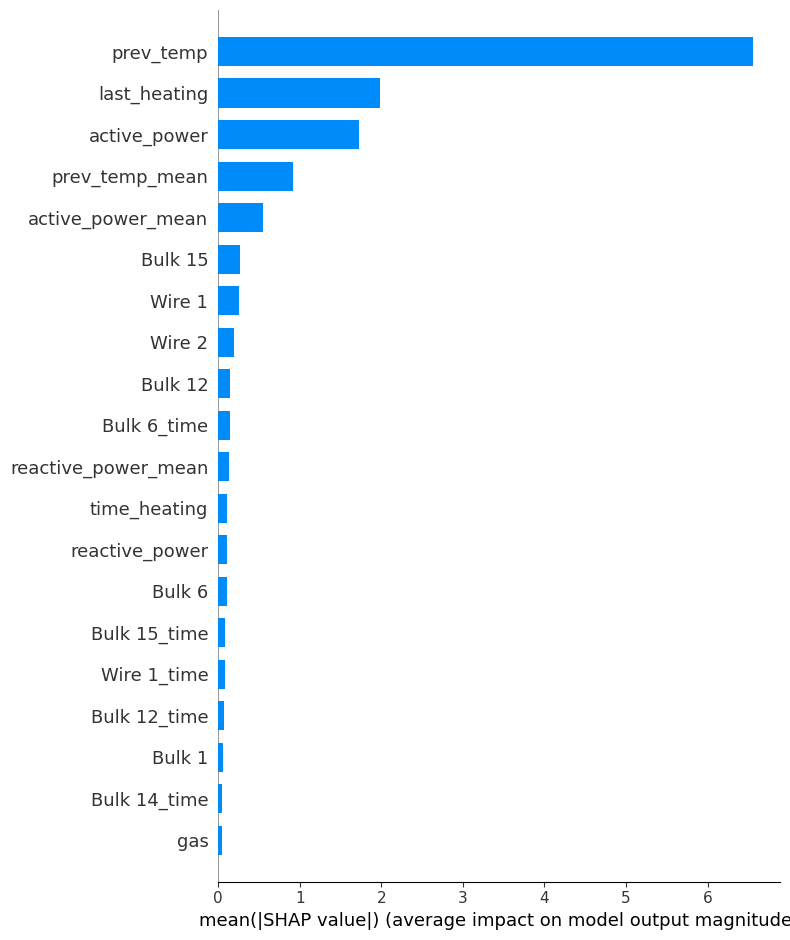

In [28]:
shap.summary_plot(shap_values, X_train, plot_type='bar')

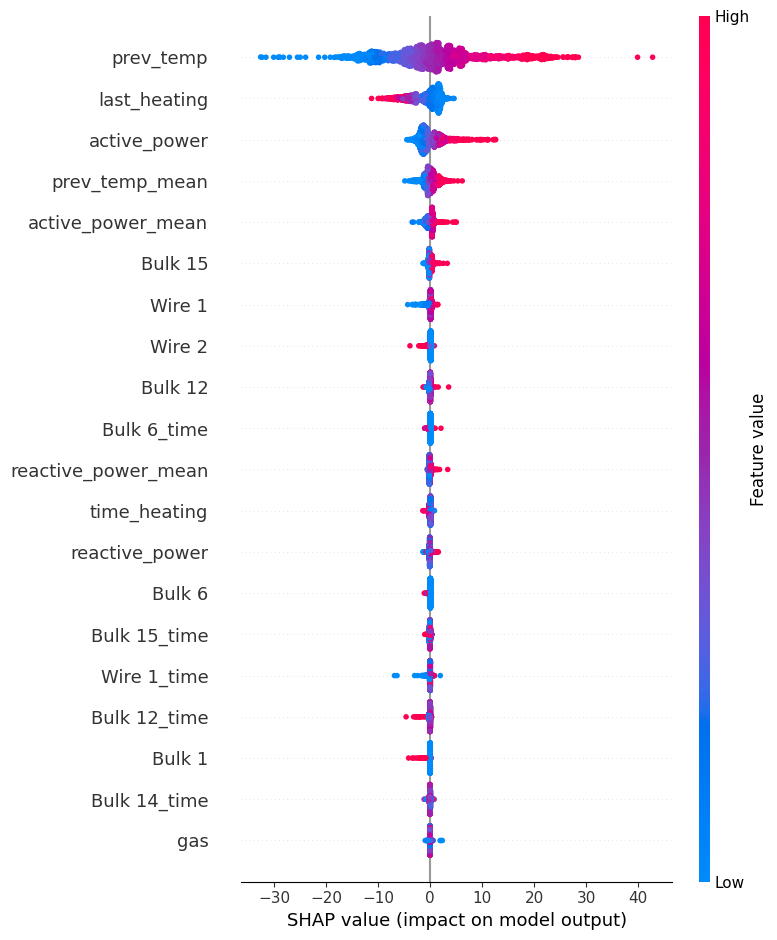

In [29]:
shap.summary_plot(shap_values, X_train)

## Отчет
- Была выполнена предобработка данных
- Анализ данных показал корректность итогового датасета
- Было построено 3 модели:
  - baseline DummyRegressor (MAE = 8.375)
  - LinearRegression (MAE = 3.293 &check;)
  - GradientBoostingRegressor с подбором гиперпараметров по сетке (MAE = 3.041 &check;)
- Лучшая модель: `GradientBoostingRegressor(max_depth=4, n_estimators=100, subsample=1.0)`
- SHAP анализ показал, что самыми важными параметрами (топ-5) являются:
  - prev_temp (температура в предыдущий замер)
  - last_heating (секунд с последнего нагревания)
  - active_power (активная мощность в последний замер)
  - prev_temp_mean (средняя предыдущая температура)
  - active_power_mean (средняя активная мощность)